# Import libaries
* In this lab, you'll be a lot more on your own. Use the following block to import your libraries
* Today we're going to work with yfinance in order to retrieve stock values. Import that library and any other that is useful (you can always come back and add some more libraries)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import sklearn.linear_model as lm

# Download some stock information
* Use yf.download() in order to download prices history for a given stock.
* Here is some doc about yfinance : https://pypi.org/project/yfinance/#quick-start
* And here is a list of tickers for stocks (I recommend you use AAPL, for Apple) : https://finance.yahoo.com/lookup/
* Use start and end parameters in the download function to limit the data from "2020-01-01" to "2024-08-31"

In [8]:
tickers = yf.Tickers('MSFT AAPL GOOG')

stocks = yf.download(['MSFT', 'AAPL', 'GOOG'], start='2020-01-01', end='2024-08-31')

msft = stocks.xs('MSFT', level=1, axis=1)
aapl = stocks.xs('AAPL', level=1, axis=1)
goog = stocks.xs('GOOG', level=1, axis=1)

msft.head()
aapl.head()
goog.head()

/var/folders/sd/2xmm9rtd4pg3v_rs5y59cbj80000gn/T/ipykernel_57676/2880586736.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download(['MSFT', 'AAPL', 'GOOG'], start='2020-01-01', end='2024-08-31')
[*********************100%***********************]  3 of 3 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,67.903824,67.942060,66.621598,66.621598,28132000
2020-01-03,67.570595,68.158574,66.819933,66.934945,23728000
2020-01-06,69.236710,69.350426,67.041231,67.041231,34646000
2020-01-07,69.193489,69.672708,69.046492,69.421929,30054000
2020-01-08,69.738762,70.099294,69.069339,69.130914,30560000


# Explore the data
* yf.download() directly creates a pandas dataframe. Explore the different columns, and visualize the data using plots.

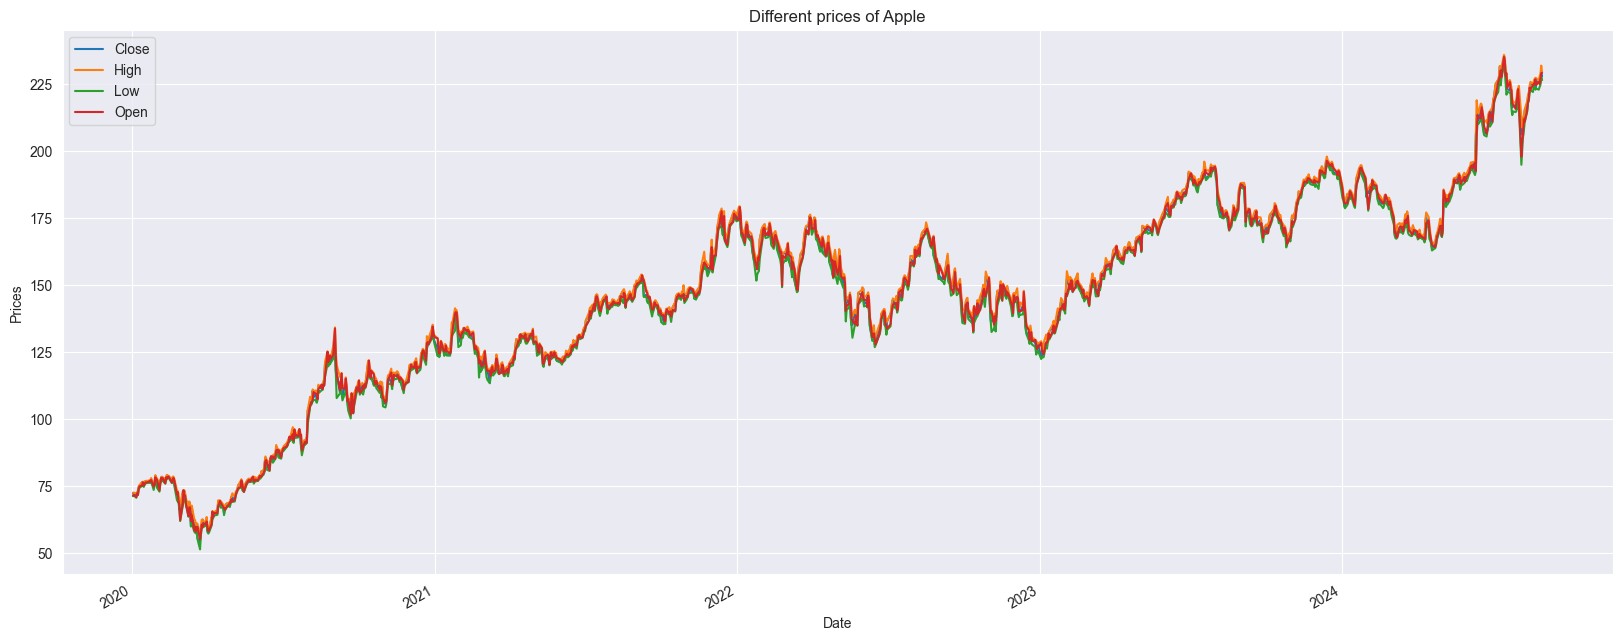

In [13]:
stocks.head()

aapl[['Close', 'High', 'Low', 'Open']].plot(figsize=(20, 8),title="Different prices of Apple",)

plt.xlabel("Date")
plt.ylabel("Prices")
plt.legend(['Close', 'High', 'Low', 'Open'])
sns.set_style("darkgrid")

# Data preprocessing
We're going to prepare the data in order to make predictions with using the Random Forest regression model from sklearn : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

* First, we need to decide on a list of features that will be used as input to the model, and one target value to predict. What would you choose as features and target ? Create one list containing the features, and another one containing the target.
* sklearn models need the values to be converted to 'numpy arrays'. That can be done directly from the pandas dataframe using 'your_dataframe[...].to_numpy()'. Replace the dots with the list of features, and store the converted values in a variable called X (that will represent the inputs). Do the same with the target, and store it in a variable called y.
* Have a look at y. It is a list of lists containing each one element. We need to change the 'shape' of y so that it is just a list of elements. You can achieve this with 'y.ravel()'.
* Now have a look at X. Some values are huge, which may cause problems during the training of the model. Use a StandardScaler() from sklearn in order to fit_transform your X.
* The last preprocessing step is to split the data into training and test sets. Use list slicing operations to keep 80% of the data as training, and the last 20% as test. Remember to split both X and y

# Creating and training the model
* Create one instance of a RandomForestRegressor with 100 estimators, and fit it on the training data

# Predicting values
* Use the test data in order to predict values

# Checking results
* We're now going to add a new column to the initial dataframe. That column will contain the predicted values. We will use this to plot both the expected and predicted values.
    * Since the predicted values only represent 20% of the data, the first 80% will be empty.
    * Initialize the values in the new column with NaN. This can be done in one line : df['your_column'] = np.nan
    * Access the last 20% rows and fill in with the predicted values. you can use df.iloc and slicing to access the range of the last 20% rows, and df.column.get_loc to locate the correct column in which values should be put : df.iloc[train_split:, df.columns.get_loc('your_column')] = your_values
    * Use df.plot() to plot the expected and predicted values at the same time. Do do that, you can give a list of columns as the 'y' parameter in the plot function.
    * What can you say about the predictions ? Why is this happening ?

# Going further : Using LSTM from keras
* That one might be a bit tricky, let's do it together ! (if there is time)
* LSTM, for Long Short Term Memory, are neural nets used to predict sequences. As such, the input must be a sequence.
* We will drop the X to make these predictions, and only use our target values y.
* The goal will be to give a sequence of values, and guess the next one.
* We will have to create a new training/test dataset, that will break down all the target values into overlapping sequences of n values that will serve as one input sample, the n+1<sup>th</sup> value being used as target y.
* So, let's create a preprocessing function that takes a sequence of values and a timestep n as parameters and returns a list of overlapping lists of length n and a list of target values.
* Here is some useful information on how to create neural nets with keras : https://keras.io/guides/sequential_model/
* The documentation on LSTM layers : https://keras.io/api/layers/recurrent_layers/lstm/
* And how to add LSTM layers : https://keras.io/examples/generative/lstm_character_level_text_generation/ (the third block of code shows how to create a simple LSTM model)